# Flight Delay Classification with Logistic Regression + SMOTE

This notebook shows how to train and evaluate a logistic‐regression classifier on a (heavily) imbalanced flight‐delay dataset by:

1. Loading and inspecting the cleaned data  
2. Defining numeric & categorical features  
3. Building a `ColumnTransformer` for preprocessing  
4. Wrapping it all in an imbalanced‐learn `Pipeline` (preprocess → SMOTE → logistic‐regression)  
5. Splitting stratified train/test, fitting, predicting  
6. Reporting classification metrics and plotting a confusion matrix  


In [1]:
# Cell 2: Imports & Settings
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection   import train_test_split
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import OneHotEncoder, StandardScaler
from imblearn.pipeline         import Pipeline as ImbPipeline
from imblearn.over_sampling    import SMOTE
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import classification_report, confusion_matrix

sns.set_style("whitegrid")


In [2]:
# Cell 3: Load the cleaned dataset
data_path = "/Users/pbat/Projects/cmor438/data/Cleaned_dataset.csv"
df = pd.read_csv(data_path)
df.head()


,Date_of_journey,Journey_day,Airline,Flight_code,Class,Source,Departure,Total_stops,Arrival,Destination,Duration_in_hours,Days_left,Fare
0,1/16/2023,Monday,SpiceJet,SG-8169,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5335
1,1/16/2023,Monday,Indigo,6E-2519,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.3333,1,5899
2,1/16/2023,Monday,GO FIRST,G8-354,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.1667,1,5801
3,1/16/2023,Monday,SpiceJet,SG-8709,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5794
4,1/16/2023,Monday,Air India,AI-805,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.1667,1,5955


In [3]:
# Cell 4: Examine class distribution
print(df['Class'].value_counts())


Class
Economy            252033
Business           126834
Premium Economy     73077
First                 144
Name: count, dtype: int64


In [4]:
# Cell 5: Define X and y
X = df.drop(columns=["Flight_code", "Class"])
y = df["Class"]


In [5]:
# Cell 6: Columns
numeric_cols     = ["Duration_in_hours", "Days_left", "Fare"]
categorical_cols = [
    "Journey_day", "Airline", "Source",
    "Departure", "Total_stops", "Arrival", "Destination"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                numeric_cols),
    ("cat", OneHotEncoder(drop="first",      sparse_output=False), categorical_cols)
])


##  Imbalanced‐learn pipeline  
1) Preprocess  
2) SMOTE up‐sampling  
3) Multinomial logistic regression (saga solver, balanced weights)


In [6]:
# Cell 7: Build the full pipeline
clf = ImbPipeline([
    ("pre",   preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("lr",    LogisticRegression(
                  multi_class="multinomial",
                  solver="saga",
                  class_weight="balanced",
                  max_iter=1000,
                  verbose=1
             ))
])


In [7]:
# Cell 8: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (361670, 11) Test shape: (90418, 11)


In [8]:
# Cell 9: Fit the pipeline and predict
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


/Users/pbat/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Epoch 1, change: 1
Epoch 2, change: 0.049958655
Epoch 3, change: 0.022853031
Epoch 4, change: 0.012815469
Epoch 5, change: 0.011800492
Epoch 6, change: 0.011210749
Epoch 7, change: 0.01038215
Epoch 8, change: 0.009572587
Epoch 9, change: 0.0085960197
Epoch 10, change: 0.0082097125
Epoch 11, change: 0.0074917874
Epoch 12, change: 0.0071287309
Epoch 13, change: 0.0066735635
Epoch 14, change: 0.0063258868
Epoch 15, change: 0.0060300653
Epoch 16, change: 0.0057014037
Epoch 17, change: 0.0054255821
Epoch 18, change: 0.0051552611
Epoch 19, change: 0.004813427
Epoch 20, change: 0.0045790117
Epoch 21, change: 0.0043770575
Epoch 22, change: 0.0041181225
Epoch 23, change: 0.003900485
Epoch 24, change: 0.0037076338
Epoch 25, change: 0.0035510521
Epoch 26, change: 0.0033229821
Epoch 27, change: 0.0031658996
Epoch 28, change: 0.0030205557
Epoch 29, change: 0.002850702
Epoch 30, change: 0.0027099133
Epoch 31, change: 0.0025831985
Epoch 32, change: 0.0024608519
Epoch 33, change: 0.00233245
Epoch 34, 

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.1min finished


                 precision    recall  f1-score   support

       Business       0.99      0.98      0.99     25367
        Economy       0.98      0.78      0.87     50407
          First       0.91      1.00      0.95        29
Premium Economy       0.55      0.93      0.69     14615

       accuracy                           0.86     90418
      macro avg       0.86      0.92      0.87     90418
   weighted avg       0.91      0.86      0.87     90418



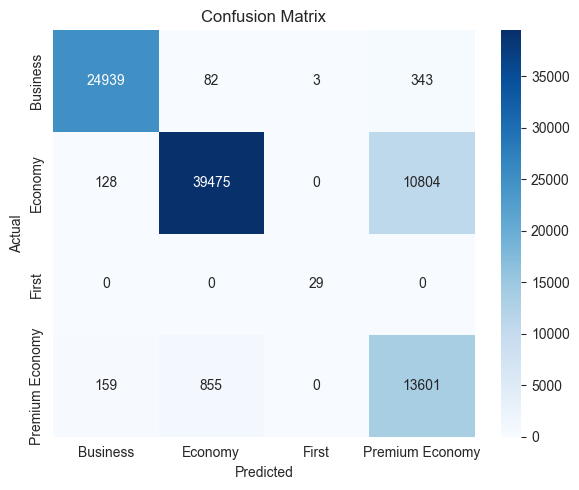

In [9]:
# Cell 10: Metrics
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=clf.classes_, yticklabels=clf.classes_,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
